In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import logging
from pathlib import Path
from hydra.utils import instantiate
from hydra import initialize_config_dir, compose
from safetensors.torch import load_file
import os
import sys
import hydra
from transformers import AutoTokenizer
import tqdm
from transformers.utils import cached_file
from typing import List
import polars as pl
import matplotlib.pyplot as plt
import json
import re

from mpramnist.Kircher2019.dataset import KircherDataset
from DescriptionLookup import DescriptionLookup
from contexts import Plasmid
from contexts import infer_table18_primer_tails
from contexts import make_mcs_insert_fn
from contexts import reverse_complement

/home/jovyan/miniconda3/envs/cagi5/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
os.environ['GENALM_HOME'] = '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark'
os.environ['PYTHONPATH'] += '/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction'

In [4]:
dataset = KircherDataset(mode='custom', elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'],
                        cell_type=['HeLa', 'HepG2', 'K562'])

In [5]:
dataset.__len__()

8778

In [3]:
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/scRNA_seq_experiments/GENA_LM/downstream_tasks/expression_prediction/datasets/data/metadata', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])

In [32]:
lookup = DescriptionLookup(json_dir='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/descriptions', keys=['HEK293T', 'HEL92.1.7', 'HaCaT', 'HeLa', 'HepG2', 'K562', 'LNCaP','MIN6', 'NIH-3T3', 'Neuro-2a', 'SF7996', 'SK-MEL-28'])

In [17]:
infer_table18_primer_tails('/home/jovyan/.cache/mpramnist/data/Kircher/hg38.fa', flank=200, min_match=15)

{'F9': ('CCCGGGCTCGAGATC', 'CCGGATTGCCAAGCT'),
 'FOXE1': ('CCCGGGCTCGAGATCT', 'CCGGATTGCCAAGCTT'),
 'GP1BB': ('CCCGGGCTCGAGATCT', 'CCGGATTGCCAAGCTT'),
 'HBB': ('CCCGGGCTCGAGATCT', 'CCGGATTGCCAAGCTT'),
 'HBG1': ('CCCGGGCTCGAGATCT', 'CCGGATTGCCAAGCTT'),
 'HNF4A': ('CCCGGGCTCGAGATC', 'CCGGATTGCCAAGCT'),
 'LDLR': ('CCCGGGCTCGAGATCT', 'CCGGATTGCCAAGCTT'),
 'MSMB': ('CCCGGGCTCGAGATC', 'CCGGATTGCCAAGCT'),
 'PKLR': ('CCCGGGCTCGAGATCT', 'CCGGATTGCCAAGCT'),
 'TERT': ('CCCGGGCTCGAGATC', 'CCGGATTGCCAAGC'),
 'SORT1': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'IRF4': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'IRF6': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'MYC (rs6983267)': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'MYC (rs11986220)': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'TCF7L2': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'ZFAND3': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'BCL11A': ('GCTCGCTAGCCTCGAG', 'CGCCGAGGCCAGATCT'),
 'UC88': ('GAGGATATCAAGATCT', 'TCTAGTGTCTAAGCTT'),
 'ZRS': ('T

In [28]:
reverse_complement('CCGGATTGCCAAGCT')

'AGCTTGGCAATCCGG'

In [2]:
seq = "atgca"
center = 1

seq_len = len(seq)

new_center = center
target = seq_len//2


while new_center != target:
    seq = seq[seq_len-1] + seq[0:-1]
    new_center += 1
print(seq)

aatgc


In [25]:
plasmid = Plasmid('https://www.ncbi.nlm.nih.gov/nuccore/MK484103.1', 
                    data_storage='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/plasmids', 
                    reporter_feature_name='similar to firefly luciferase; synthetic luc2 version of the luciferase gene')

In [26]:
plasmid_context = plasmid.plasmid_context(insert_fn=make_mcs_insert_fn('CCCGGGCTCGAGATC', 'CCGGATTGCCAAGCT'), context_size=10_000, circular=True)

In [ ]:
class CAGI5_bench():
    
    def __init__(self, 
                    model_cls:str,
                    model_checkpoint:str,
                    model_config:str,
                    dna_tokenizer:str,
                    desc_tokenizer:str,
                    dna_max_seq_len:int,
                    desc_max_seq_len:int,
                    token_len_for_fetch:int,
                    num_before:int,
                    celltype2desc:dict|DescriptionLookup
                    ):
        self.dataset = None
        self.logger = logging.getLogger(__name__)
        self.model_cls = model_cls
        self.model_config = model_config
        self.model_checkpoint = model_checkpoint
        self.dna_tokenizer = AutoTokenizer.from_pretrained(dna_tokenizer)
        self.cls_id = self.dna_tokenizer.cls_token_id
        self.sep_id = self.dna_tokenizer.sep_token_id
        self.pad_id = self.dna_tokenizer.pad_token_id
        
        self.desc_tokenizer = AutoTokenizer.from_pretrained(desc_tokenizer, padding_side="left")
        self.token_len_for_fetch = token_len_for_fetch
        self.dna_max_seq_len = dna_max_seq_len
        self.dna_max_seq_tokens = dna_max_seq_len - 2
        self.desc_max_seq_len = desc_max_seq_len
        self.desc_max_seq_tokens = desc_max_seq_len - 2
        self.device = 'cuda:6' if torch.cuda.is_available() else 'cpu'
        self.num_before = num_before
        
        self.celltype2desc = celltype2desc
        
    
    def initialize_dataset(self, 
                            elements:list|None = None, 
                            cell_type:list|None = None, 
                            transform=None, 
                            target_transform=None, 
                            root=None,
                            context_fn = lambda x: x):
        def _make_transform(context_fn = context_fn):
            def transform(sequence:str):
                sequence_in_context = context_fn(sequence)
                return self.tokenize_sequence_centered(sequence_in_context)
            return transform
                
        
        self.dataset = KircherDataset(elements=elements, length=300, cell_type=cell_type, transform=_make_transform() if transform is None else transform, target_transform=target_transform, root=root)
        
    def make_dataloader(self, 
                        batch_size:int, 
                        n_workers:int):
        def make_collate_fn(dataset_flag:int = 0):
            
            def collate_fn(batch):
                #batch_descriptions = [self.make_description_from_json(item[2]) for item in batch] #item[2] - cell type
                batch_descriptions = [self.make_description_from_json(
                                                                    self.celltype2desc[item[2]]
                                                                            ) for item in batch]
                
                batch_tokenized_descriptions = [self.tokenize_description(desc) for desc in batch_descriptions]
                
                batched = {
                    'dna_input_ids_wt': torch.stack([item[0]['seq']['dna_input_ids'] for item in batch]),
                    'dna_input_ids_alt': torch.stack([item[0]['seq_alt']['dna_input_ids'] for item in batch]),
                    'dna_attention_mask_wt': torch.stack([item[0]['seq']['dna_attention_mask'] for item in batch]),
                    'dna_attention_mask_alt': torch.stack([item[0]['seq_alt']['dna_attention_mask'] for item in batch]),
                    'difference': torch.stack([item[1].clone().detach() for item in batch]),
                    'desc_input_ids': torch.stack([desc_encoded['desc_input_ids'] for desc_encoded in batch_tokenized_descriptions]),
                    'desc_attention_mask': torch.stack([desc_encoded['desc_attention_mask'] for desc_encoded in batch_tokenized_descriptions]),
                    'dataset_flag': torch.stack([torch.tensor(dataset_flag) for _ in range(len(batch))]).unsqueeze(-1),
                    'element': [item[3] for item in batch]
                }
                return batched
            return collate_fn
        
        
        self.dataloader = DataLoader(dataset = self.dataset, collate_fn=make_collate_fn(), batch_size=batch_size, num_workers=n_workers, shuffle=False)
        
    def initialize_model(self):
        self.logger.info(f'Loading model on {self.device}')
        cls = hydra.utils.get_class(self.model_cls)
        config_path = Path(self.model_config)
        with initialize_config_dir(str(config_path.parents[0])):
            experiment_config = compose(config_name=config_path.name)
        model_kwargs = instantiate(experiment_config['model_kwargs'])
        model = cls(**model_kwargs)
        if Path(self.model_checkpoint).suffix == '.tensors':
            state_dict = load_file(self.model_checkpoint, device='cpu')
        else:
            state_dict = torch.load(self.model_checkpoint, map_location=torch.device('cpu'), weights_only=True)

        model.load_state_dict(state_dict)
        self.model = model.to(self.device)
        self.model.eval()
    
    
    def reverse_complement(self, sequence):
        complement = str.maketrans('ACGTN', 'TGCAN')
        return sequence.translate(complement)[::-1]


    def tokenize_sequence_centered(self, sequence: str, strand: str = "+"):
        """
        Tokenize a DNA sequence centered on TSS.
        Returns a flat list of token IDs with CLS at start and SEP at end.
        """
        sequence = sequence.upper()
        
        reverse = (strand == "-")
        tss_pos = len(sequence) // 2  # TSS always in the middle
        tokens = []

        # 1. UPSTREAM (5' side of TSS)
        if self.num_before > 0:
            fetch_len = self.num_before * self.token_len_for_fetch
            if not reverse:
                up_seq = sequence[max(0, tss_pos - fetch_len):tss_pos]
            else:
                up_seq = sequence[tss_pos:min(len(sequence), tss_pos + fetch_len)]
                up_seq = self.reverse_complement(up_seq)
                
            enc = self.dna_tokenizer.encode_plus(up_seq, return_offsets_mapping=False)
            up_tokens = enc['input_ids'][1:-1]  # strip auto-added CLS/SEP
            
            if len(up_tokens) < self.num_before:
                self.logger.warning(f"Upstream too short: {len(up_tokens)} < {self.num_before}")
                
            tokens.extend(up_tokens[-self.num_before:])

        # 2. DOWNSTREAM (3' side of TSS)
        if not reverse:
            down_seq = sequence[tss_pos:]
        else:
            down_seq = sequence[:tss_pos]
            down_seq = self.reverse_complement(down_seq)
            
        enc = self.dna_tokenizer.encode_plus(down_seq, return_offsets_mapping=False)
        tokens.extend(enc['input_ids'][1:-1][0:self.dna_max_seq_tokens-self.num_before])

        # 3. ORIENTATION & SPECIAL TOKENS
        if reverse:
            tokens.reverse()  # maintain 5' -> 3' transcriptional order
        
        input_ids =  [self.cls_id] + tokens + [self.sep_id]
        if len(input_ids) != 1024:
            raise ValueError(f'len of input_ids is less then 1024 tokens: {len(input_ids)}')
        return {'dna_input_ids': torch.tensor(input_ids), 'dna_attention_mask': torch.tensor([1 for _ in range(len(input_ids))])}
    
    @staticmethod
    def make_description_from_json(meta):
        line_texts = []
        for k, v in meta.items():
            k = k.replace('_', ' ')
            v = str(v).replace('_', ' ')
            clean_k = re.sub(r'^(Characteristics|Chracteristics|Charateristics|Parameter)\\s*', '', k)
            clean_k = re.sub(r'\\[|\\]', '', clean_k).strip()
            clean_k = clean_k if clean_k else k
            clean_v = str(v).replace('"', '').strip()
            line_texts.append(f'{clean_k} is {clean_v}.')
        return " ".join(line_texts)
    
    
    def tokenize_description(self, description):
        
        #def _padding(input_ids, attention_mask):
        encoding = self.desc_tokenizer(description, 
                                        padding='max_length',
                                        padding_side='right',
                                        truncation=True,
                                        max_length=self.desc_max_seq_tokens,
                                        return_tensors="pt")
        input_ids = encoding["input_ids"][0]
        attention_mask = encoding["attention_mask"][0]
        
        return {'desc_input_ids':input_ids, 'desc_attention_mask': attention_mask}
    
    
    def run_inference(self):
        
        
        with torch.autocast(device_type="cuda"), torch.inference_mode():
            
            true_vs_pred = None
            
            for batch in tqdm.tqdm(self.dataloader):
                
                #element = batch['elements'][0]
                
                desc_input_ids = batch['desc_input_ids'].to(self.device)  # stays long
                desc_attention_mask = batch['desc_attention_mask'].to(self.device)  # stays long/bool
                dataset_flag = batch['dataset_flag'].to(self.device, dtype=torch.bool)  # bool for indexing
                
                wt_model_output = self.model(
                    input_ids=batch['dna_input_ids_wt'].to(self.device),
                    attention_mask=batch['dna_attention_mask_wt'].to(self.device),
                    labels_mask=None,
                    labels=None,
                    return_dict=None,
                    desc_input_ids=desc_input_ids,
                    desc_attention_mask=desc_attention_mask,
                    dataset_flag=dataset_flag,
                )
                
                alt_model_output = self.model(
                    input_ids=batch['dna_input_ids_alt'].to(self.device),  # ← long, not bfloat16
                    attention_mask=batch['dna_attention_mask_alt'].to(self.device),
                    labels_mask=None,
                    labels=None,
                    return_dict=None,
                    desc_input_ids=batch['desc_input_ids'].to(self.device),  # ← long
                    desc_attention_mask=batch['desc_attention_mask'].to(self.device),
                    dataset_flag=dataset_flag,  # ← bool
                )
                
                target_difference = batch['difference'].unsqueeze(-1).to(self.device) #shape (batch_size, 1)
                
                predicted_difference = -1 * (wt_model_output.logits[:, 0:1, :] - alt_model_output.logits[:, 0:1, :]).squeeze(-1) # (batch size, 1)
                
                concat_tensor = torch.cat((target_difference, predicted_difference), dim=1).float() #batch_size, 2
                #print(f'''
                #    concat tensor shape: {concat_tensor.shape}
                #    target difference shape: {target_difference.shape}
                #    abs_predicted_difference shape: {abs_predicted_difference.shape}
                #      ''')
                
                if true_vs_pred is None:
                    true_vs_pred = concat_tensor #batch_size, 2
                else:
                    true_vs_pred = torch.cat((true_vs_pred, concat_tensor), dim=0) #batch_size * n_batches , 2
                #print(f'true_vs_pred shape: {true_vs_pred.shape}')
            assert true_vs_pred is not None
            self.true_vs_pred = true_vs_pred
            self.corr = torch.corrcoef(true_vs_pred.T)

In [ ]:
class CAGI5_bench():
    
    def __init__(self, 
                    model_cls:str,
                    model_checkpoint:str,
                    model_config:str,
                    dna_tokenizer:str,
                    desc_tokenizer:str,
                    dna_max_seq_len:int,
                    desc_max_seq_len:int,
                    token_len_for_fetch:int,
                    num_before:int,
                    celltype2desc:dict|DescriptionLookup
                    ):
        self.dataset = None
        self.logger = logging.getLogger(__name__)
        self.model_cls = model_cls
        self.model_config = model_config
        self.model_checkpoint = model_checkpoint
        self.dna_tokenizer = AutoTokenizer.from_pretrained(dna_tokenizer)
        self.cls_id = self.dna_tokenizer.cls_token_id
        self.sep_id = self.dna_tokenizer.sep_token_id
        self.pad_id = self.dna_tokenizer.pad_token_id
        
        self.desc_tokenizer = AutoTokenizer.from_pretrained(desc_tokenizer, padding_side="right")
        self.token_len_for_fetch = token_len_for_fetch
        self.dna_max_seq_len = dna_max_seq_len
        self.dna_max_seq_tokens = dna_max_seq_len - 2
        self.desc_max_seq_len = desc_max_seq_len
        self.desc_max_seq_tokens = desc_max_seq_len - 2
        self.device = 'cuda:6' if torch.cuda.is_available() else 'cpu'
        self.num_before = num_before
        
        self.celltype2desc = celltype2desc
        
    
    def initialize_dataset(self, 
                            elements:list|None = None, 
                            cell_type:list|None = None,
                            transform=None, 
                            target_transform=None, 
                            root=None,
                            context_fn = lambda seq: seq):
        def _make_transform(context_fn = context_fn):
            def transform(sequence:str):
                sequence_in_context = context_fn(sequence)
                return self.tokenize_sequence_centered(sequence_in_context)
            return transform
                
        
        self.dataset = KircherDataset(elements=elements, mode='custom', cell_type=cell_type, transform=_make_transform() if transform is None else transform, target_transform=target_transform, root=root)
        
    def make_dataloader(self, 
                        batch_size:int, 
                        n_workers:int):
        def make_collate_fn(dataset_flag:int = 0):
            
            def collate_fn(batch):
                #batch_descriptions = [self.make_description_from_json(item[2]) for item in batch] #item[2] - cell type
                batch_descriptions = [self.make_description_from_json(
                                                                    self.celltype2desc[item[2]]
                                                                            ) for item in batch]
                
                batch_tokenized_descriptions = [self.tokenize_description(desc) for desc in batch_descriptions]
                
                batched = {
                    'dna_input_ids_wt': torch.stack([item[0]['seq']['dna_input_ids'] for item in batch]),
                    'dna_input_ids_alt': torch.stack([item[0]['seq_alt']['dna_input_ids'] for item in batch]),
                    'dna_attention_mask_wt': torch.stack([item[0]['seq']['dna_attention_mask'] for item in batch]),
                    'dna_attention_mask_alt': torch.stack([item[0]['seq_alt']['dna_attention_mask'] for item in batch]),
                    'difference': torch.stack([item[1].clone().detach() for item in batch]),
                    'desc_input_ids': torch.stack([desc_encoded['desc_input_ids'] for desc_encoded in batch_tokenized_descriptions]),
                    'desc_attention_mask': torch.stack([desc_encoded['desc_attention_mask'] for desc_encoded in batch_tokenized_descriptions]),
                    'dataset_flag': torch.stack([torch.tensor(dataset_flag) for _ in range(len(batch))]).unsqueeze(-1),
                    'element': [item[3] for item in batch]
                }
                return batched
            return collate_fn
        
        
        self.dataloader = DataLoader(dataset = self.dataset, collate_fn=make_collate_fn(), batch_size=batch_size, num_workers=n_workers, shuffle=False)
        
    def initialize_model(self):
        self.logger.info(f'Loading model on {self.device}')
        cls = hydra.utils.get_class(self.model_cls)
        config_path = Path(self.model_config)
        with initialize_config_dir(str(config_path.parents[0])):
            experiment_config = compose(config_name=config_path.name)
        model_kwargs = instantiate(experiment_config['model_kwargs'])
        model = cls(**model_kwargs)
        if Path(self.model_checkpoint).suffix == '.tensors':
            state_dict = load_file(self.model_checkpoint, device='cpu')
        else:
            state_dict = torch.load(self.model_checkpoint, map_location=torch.device('cpu'), weights_only=True)

        model.load_state_dict(state_dict)
        self.model = model.to(self.device)
        self.model.eval()
    
    
    def reverse_complement(self, sequence):
        complement = str.maketrans('ACGTN', 'TGCAN')
        return sequence.translate(complement)[::-1]


    def tokenize_sequence_centered(self, sequence: str, strand: str = "+"):
        """
        Tokenize a DNA sequence centered on TSS.
        Returns a flat list of token IDs with CLS at start and SEP at end.
        """
        sequence = sequence.upper()
        
        reverse = (strand == "-")
        tss_pos = len(sequence) // 2  # TSS always in the middle
        tokens = []

        # 1. UPSTREAM (5' side of TSS)
        if self.num_before > 0:
            fetch_len = self.num_before * self.token_len_for_fetch
            if not reverse:
                up_seq = sequence[max(0, tss_pos - fetch_len):tss_pos]
            else:
                up_seq = sequence[tss_pos:min(len(sequence), tss_pos + fetch_len)]
                up_seq = self.reverse_complement(up_seq)
                
            enc = self.dna_tokenizer.encode_plus(up_seq, return_offsets_mapping=False)
            up_tokens = enc['input_ids'][1:-1]  # strip auto-added CLS/SEP
            
            if len(up_tokens) < self.num_before:
                self.logger.warning(f"Upstream too short: {len(up_tokens)} < {self.num_before}")
                
            tokens.extend(up_tokens[-self.num_before:])

        # 2. DOWNSTREAM (3' side of TSS)
        if not reverse:
            down_seq = sequence[tss_pos:]
        else:
            down_seq = sequence[:tss_pos]
            down_seq = self.reverse_complement(down_seq)
            
        enc = self.dna_tokenizer.encode_plus(down_seq, return_offsets_mapping=False)
        tokens.extend(enc['input_ids'][1:-1][0:self.dna_max_seq_tokens-self.num_before])

        # 3. ORIENTATION & SPECIAL TOKENS
        if reverse:
            tokens.reverse()  # maintain 5' -> 3' transcriptional order
        
        input_ids =  [self.cls_id] + tokens + [self.sep_id]
        if len(input_ids) != 1024:
            raise ValueError(f'len of input_ids is less then 1024 tokens: {len(input_ids)}')
        return {'dna_input_ids': torch.tensor(input_ids), 'dna_attention_mask': torch.tensor([1 for _ in range(len(input_ids))])}
    
    @staticmethod
    def make_description_from_json(meta):
        line_texts = []
        for k, v in meta.items():
            k = k.replace('_', ' ')
            v = str(v).replace('_', ' ')
            clean_k = re.sub(r'^(Characteristics|Chracteristics|Charateristics|Parameter)\\s*', '', k)
            clean_k = re.sub(r'\\[|\\]', '', clean_k).strip()
            clean_k = clean_k if clean_k else k
            clean_v = str(v).replace('"', '').strip()
            line_texts.append(f'{clean_k} is {clean_v}.')
        return " ".join(line_texts)
    
    
    def tokenize_description(self, description):
        
        #def _padding(input_ids, attention_mask):
        encoding = self.desc_tokenizer(description, 
                                        padding='max_length',
                                        padding_side='right',
                                        truncation=True,
                                        max_length=self.desc_max_seq_tokens,
                                        return_tensors="pt")
        input_ids = encoding["input_ids"][0]
        attention_mask = encoding["attention_mask"][0]
        
        return {'desc_input_ids':input_ids, 'desc_attention_mask': attention_mask}
    
    
    def run_inference(self):
        
        
        with torch.autocast(device_type='cuda'), torch.inference_mode():
            
            true_vs_pred = {}
            
            for batch in tqdm.tqdm(self.dataloader):
                
                element = batch['element'][0]
                
                desc_input_ids = batch['desc_input_ids'].to(self.device)  # stays long
                desc_attention_mask = batch['desc_attention_mask'].to(self.device)  # stays long/bool
                dataset_flag = batch['dataset_flag'].to(self.device, dtype=torch.bool)  # bool for indexing
                
                wt_model_output = self.model(
                    input_ids=batch['dna_input_ids_wt'].to(self.device),
                    attention_mask=batch['dna_attention_mask_wt'].to(self.device),
                    labels_mask=None,
                    labels=None,
                    return_dict=None,
                    desc_input_ids=desc_input_ids,
                    desc_attention_mask=desc_attention_mask,
                    dataset_flag=dataset_flag,
                )
                
                alt_model_output = self.model(
                    input_ids=batch['dna_input_ids_alt'].to(self.device),  # ← long, not bfloat16
                    attention_mask=batch['dna_attention_mask_alt'].to(self.device),
                    labels_mask=None,
                    labels=None,
                    return_dict=None,
                    desc_input_ids=batch['desc_input_ids'].to(self.device),  # ← long
                    desc_attention_mask=batch['desc_attention_mask'].to(self.device),
                    dataset_flag=dataset_flag,  # ← bool
                )
                
                target_difference = batch['difference'].unsqueeze(-1).to(self.device) #shape (batch_size, 1)
                
                predicted_difference = (alt_model_output.logits[:, 0:1, :] - wt_model_output.logits[:, 0:1, :]).squeeze(-1) # (batch size, 1)
                
                concat_tensor = torch.cat((target_difference, predicted_difference), dim=1).float() #batch_size, 2
                #print(f'''
                #    concat tensor shape: {concat_tensor.shape}
                #    target difference shape: {target_difference.shape}
                #    abs_predicted_difference shape: {abs_predicted_difference.shape}
                #      ''')
                
                if element not in true_vs_pred:
                    true_vs_pred[element] = concat_tensor
                else:
                    true_vs_pred[element] = torch.cat((true_vs_pred[element], concat_tensor), dim=0) #batch_size * n_batches , 2
                
            assert true_vs_pred is not None
            self.true_vs_pred = true_vs_pred
            
            self.corr = {el : torch.corrcoef(value.float().T) for el, value in true_vs_pred.items()}
            
    
            

In [33]:
bench = CAGI5_bench(model_cls='downstream_tasks.expression_prediction.expression_model_final.ExpressionCounts', 
            model_checkpoint='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/models/expression_model/pytorch_model.bin',
            model_config='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/configs/final.yaml',
            dna_tokenizer='/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/data/tokenizers/t2t_1000h_multi_32k',
            desc_max_seq_len=1024,
            token_len_for_fetch=10,
            desc_tokenizer="Qwen/Qwen3-Embedding-0.6B",
            dna_max_seq_len=1024,
            num_before=511,
            celltype2desc=lookup)

In [ ]:
bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'])
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

In [ ]:
#bench.initialize_dataset(elements=['F9','FOXE1','GP1BA','HBB','HBG1','HNF4A','LDLR','LDLR.2','MSMB','PKLR-24h','PKLR-48h','TERT-GAa','TERT-GBM','TERT-GSc','TERT-HEK'],
#                            cell_type=['HepG2', 'HeLa', 'K562'])
bench.initialize_dataset(elements=['F9'], cell_type=['HepG2', 'HeLa', 'K562'])
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

In [ ]:
bench.initialize_dataset(elements=['LDLR', 'F9'], cell_type=['HepG2'])
bench.make_dataloader(batch_size=1, n_workers=5)
bench.initialize_model()

In [22]:
plasmid_context('RRRRRRR').__len__()

10000

In [35]:
bench.run_inference()

100%|██████████| 18468/18468 [43:23<00:00,  7.09it/s]


In [21]:
bench.true_vs_pred

{'F9': tensor([[-0.2800, -0.0048],
         [ 0.0500,  0.0123],
         [-1.0700, -0.0108],
         ...,
         [ 0.1200,  0.0073],
         [-0.0800, -0.0086],
         [ 0.0100, -0.0060]], device='cuda:6')}

In [36]:
bench.corr

{'F9': tensor([[1.0000, 0.0544],
         [0.0544, 1.0000]], device='cuda:6', dtype=torch.float16),
 'FOXE1': tensor([[0.9995, 0.0509],
         [0.0509, 1.0000]], device='cuda:6', dtype=torch.float16),
 'GP1BA': tensor([[ 1.0000, -0.0485],
         [-0.0485,  1.0000]], device='cuda:6', dtype=torch.float16),
 'HBB': tensor([[1.0000, 0.0403],
         [0.0403, 1.0000]], device='cuda:6', dtype=torch.float16),
 'HBG1': tensor([[1.0000, 0.1238],
         [0.1237, 1.0000]], device='cuda:6', dtype=torch.float16),
 'HNF4A': tensor([[ 1.0000, -0.0701],
         [-0.0701,  1.0000]], device='cuda:6', dtype=torch.float16),
 'LDLR': tensor([[0.9995, 0.4170],
         [0.4170, 1.0000]], device='cuda:6', dtype=torch.float16),
 'LDLR.2': tensor([[1.0000, 0.4270],
         [0.4272, 1.0000]], device='cuda:6', dtype=torch.float16),
 'MSMB': tensor([[1.0000, 0.0188],
         [0.0188, 0.9990]], device='cuda:6', dtype=torch.float16),
 'PKLR-24h': tensor([[ 1.0000, -0.0737],
         [-0.0736,  1.0000]], d

In [29]:
bench.true_vs_pred

{'F9': tensor([[-0.2800,  0.1094],
         [ 0.0500, -0.0762],
         [-1.0700,  0.0215],
         ...,
         [ 0.1200, -0.0176],
         [-0.0800,  0.0215],
         [ 0.0100,  0.0117]], device='cuda:6'),
 'FOXE1': tensor([[ 0.5800, -0.0586],
         [ 0.0300, -0.1836],
         [-0.1800, -0.0742],
         ...,
         [-2.3600, -0.0625],
         [-0.1900,  0.2227],
         [ 0.0800,  0.2461]], device='cuda:6'),
 'GP1BA': tensor([[-0.3200, -0.0225],
         [-0.0400,  0.0010],
         [ 0.0000,  0.0410],
         ...,
         [-0.0200,  0.0278],
         [ 0.0100,  0.0098],
         [ 0.0100,  0.0269]], device='cuda:6'),
 'HBB': tensor([[-0.5100,  0.0100],
         [-0.0200,  0.0215],
         [ 0.0400,  0.0269],
         ...,
         [-0.0400,  0.0659],
         [-0.0700,  0.0403],
         [-0.1700,  0.2600]], device='cuda:6'),
 'HBG1': tensor([[ 0.0900,  0.4551],
         [ 0.1900,  0.4824],
         [ 0.0700,  0.5645],
         ...,
         [-0.0400,  0.3877],
   

In [30]:
bench.corr

{'F9': tensor([[ 1.0000, -0.0052],
         [-0.0052,  1.0000]], device='cuda:6', dtype=torch.float16),
 'FOXE1': tensor([[0.9995, 0.0091],
         [0.0091, 1.0000]], device='cuda:6', dtype=torch.float16),
 'GP1BA': tensor([[ 1.0000, -0.1683],
         [-0.1683,  1.0000]], device='cuda:6', dtype=torch.float16),
 'HBB': tensor([[1.0000, 0.1036],
         [0.1035, 1.0000]], device='cuda:6', dtype=torch.float16),
 'HBG1': tensor([[ 1.0000, -0.1527],
         [-0.1527,  0.9995]], device='cuda:6', dtype=torch.float16),
 'HNF4A': tensor([[1.0000, 0.0013],
         [0.0013, 1.0000]], device='cuda:6', dtype=torch.float16),
 'LDLR': tensor([[0.9995, 0.4824],
         [0.4822, 1.0000]], device='cuda:6', dtype=torch.float16),
 'LDLR.2': tensor([[1.0000, 0.5215],
         [0.5215, 1.0000]], device='cuda:6', dtype=torch.float16),
 'MSMB': tensor([[1.0000, 0.0049],
         [0.0049, 1.0000]], device='cuda:6', dtype=torch.float16),
 'PKLR-24h': tensor([[ 1.0000, -0.0602],
         [-0.0602,  1.0000]

In [14]:
torch.corrcoef(bench.true_vs_pred.T)

tensor([[1.0000, 0.5113],
        [0.5113, 1.0000]], device='cuda:6')

Text(0.5, 1.0, 'True vs pred difference')

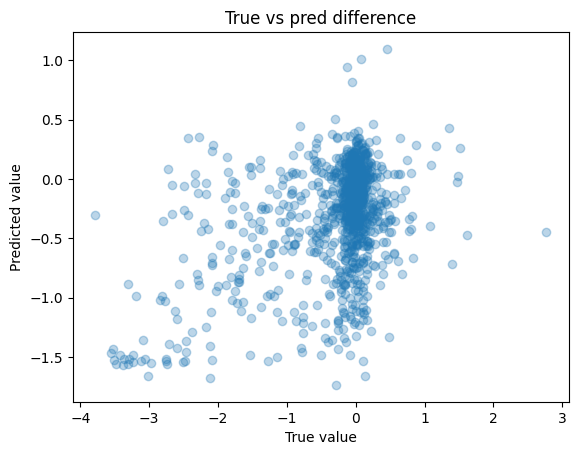

In [41]:
plt.scatter(x=bench.true_vs_pred['LDLR.2'][:, 0].cpu(), y = bench.true_vs_pred['LDLR.2'][:, 1].cpu(), alpha=0.3)
plt.xlabel('True value')
plt.ylabel('Predicted value')
plt.title('True vs pred difference')

In [82]:
import polars as pl

In [88]:
pl.read_csv('/workspace-SR003.nfs2/estsoi/CAGI5_benchmark/GENA_LM/downstream_tasks/expression_prediction/CAGI5_benchmark/data/dataset.csv', separator='\t', ignore_errors=True)

Element,Cell_Type,Chromosome,Position,Ref,Alt,Tags,DNA,RNA,Value,P-Value
str,str,i64,i64,str,str,i64,i64,i64,f64,f64
"""BCL11A""","""HEL92.1.7""",2,60494939,"""C""","""-""",32,577,1345,-0.34,0.00546
"""BCL11A""","""HEL92.1.7""",2,60494939,"""C""","""A""",146,2785,6772,-0.05,0.38889
"""BCL11A""","""HEL92.1.7""",2,60494939,"""C""","""G""",60,975,2436,-0.13,0.13721
"""BCL11A""","""HEL92.1.7""",2,60494939,"""C""","""T""",1084,8543,16057,-0.7,0.0
"""BCL11A""","""HEL92.1.7""",2,60494940,"""C""","""A""",596,9425,23430,-0.08,0.00413
…,…,…,…,…,…,…,…,…,…,…
"""ZRSh-13h2""","""NIH-3T3""",7,156791602,"""C""","""-""",1447,11717,34300,0.04,0.11224
"""ZRSh-13h2""","""NIH-3T3""",7,156791602,"""C""","""A""",25,107,309,-0.17,0.33374
"""ZRSh-13h2""","""NIH-3T3""",7,156791602,"""C""","""G""",654,4748,14458,0.06,0.09092
